# PointNet++ Training experimental

This notebook serves the purpose of creating the training routine for the PointNet++ to encode point clouds into the same latent space as the CAD sequence encoding done by the DeepCAD model.

The pointnet venv is located at "Point-Cloud-Reconstruction/pointnet.pytorch", but the model used is in "Point-Cloud-Reconstruction/Pointnet_Pointnet2_pytorch"

## 1. Check point cloud data
We will use open3d to inspect the point cloud files. During the conversion of the CAD sequences to point clouds errors appeared, which is why I assume there must be some corrupt point cloud files, which need to be excluded.

- Load train/val/test split
- create train/val/test pc path lists

In [1]:
import open3d as o3d
import os
from tqdm import tqdm
from glob import glob
import h5py
import numpy as np
import torch

In [2]:
DATA_ROOT = "../data"

PC_ROOT = os.path.join(DATA_ROOT, "pc_cad")
SPLIT = os.path.join(DATA_ROOT, "train_val_test_split.json")

Here the split file is opened, it contains the information about all files in the dataset

In [3]:
with open(SPLIT, "r") as fp:
    all_data = json.load(fp)
print(f"Number of samples that should be in the split: {len(all_data['train']) + len(all_data['validation']) + len(all_data['test'])}")
for phase in all_data.keys():
    print(phase, len(all_data[phase]))

Number of samples that should be in the split: 178238
train 161240
validation 8946
test 8052


In [4]:
train = [os.path.join(PC_ROOT, f"{idx}.ply") for idx in all_data['train']]
val = [os.path.join(PC_ROOT, f"{idx}.ply") for idx in all_data['validation']]
test = [os.path.join(PC_ROOT, f"{idx}.ply") for idx in all_data['test']]

Now we need to check if the point cloud files in the split are actually there and not corrupt. The point cloud files are generated using json2pc.py, which can fail from time to time.

In [5]:
file_pattern = "**/*.ply"
all_files = glob(f"{PC_ROOT}/{file_pattern}", recursive=True)
print(f"Total number of files: {len(all_files)}")
print(f"Missing files: {len(train)+len(val)+len(test)-len(all_files)}")

Total number of files: 177948
Missing files: 290


Apparently in 290 cases no point cloud file was created. These have to be removed from the split. Therefore we filter all files in the split by the files which are actually on disk. Then we obtain the indices of the removed files, in order to later remove the respective latent representations.

In [6]:
all_files_set = set(all_files)

train_pc = [entry for entry in train if entry in all_files_set]
corrupt_files_idx_train = [i for i, entry in enumerate(train) if entry not in all_files_set]

val_pc = [entry for entry in val if entry in all_files_set]
corrupt_files_idx_val = [i for i, entry in enumerate(val) if entry not in all_files_set]

test_pc = [entry for entry in test if entry in all_files_set]
corrupt_files_idx_test = [i for i, entry in enumerate(test) if entry not in all_files_set]

In [7]:
assert (len(train_pc)+len(val_pc)+len(test_pc) == len(all_files))

In [133]:
def check_valid_pc(paths_list):
    corrupt_counter = 0
    for pc_file in tqdm(paths_list):
        try:
            pc = o3d.io.read_point_cloud(pc_file)
            if not pc.has_points():
                corrupt_counter += 1
        except Exception as e:
            corrupt_counter += 1
    print(f"There are {corrupt_counter} corrupt files")
    if corrupt_counter == 0:
        return True
    else:
        return False

In [134]:
print("Check train set")
assert(check_valid_pc(train_pc))
print("Check val set")
assert(check_valid_pc(val_pc))
print("Check test set")
assert(check_valid_pc(test_pc))

Check train set


100%|█████████████████████████████████| 160982/160982 [01:54<00:00, 1411.71it/s]


There are 0 corrupt files
Check val set


100%|█████████████████████████████████████| 8928/8928 [00:06<00:00, 1390.14it/s]


There are 0 corrupt files
Check test set


100%|█████████████████████████████████████| 8038/8038 [00:05<00:00, 1369.33it/s]

There are 0 corrupt files


## Check latent representation

In [8]:
LATENT_ROOT = os.path.join(DATA_ROOT, "latent/pretrained/results/all_zs_ckpt1000.h5")

In [9]:
with h5py.File(LATENT_ROOT, 'r') as f:
    for key in f.keys():
        print(f"key - {key}: {f[key]}")
    train_latent = np.array(f["train_zs"])
    val_latent = np.array(f["validation_zs"])
    test_latent = np.array(f["test_zs"])

key - test_zs: <HDF5 dataset "test_zs": shape (8052, 256), type "<f4">
key - train_zs: <HDF5 dataset "train_zs": shape (161240, 256), type "<f4">
key - validation_zs: <HDF5 dataset "validation_zs": shape (8946, 256), type "<f4">


In [10]:
def check_latent_valid(data):
    # Zero rows
    zero_rows = np.all(data == 0, axis=1)
    num_zero_rows = np.sum(zero_rows)
    if num_zero_rows > 0:
        print(f"There are {num_zero_rows} zero rows.")
    
    # NaN or Inf values
    nan_or_inf_rows = np.any(np.isnan(data) | np.isinf(data), axis=1)
    num_nan_or_inf_rows = np.sum(nan_or_inf_rows)
    if num_nan_or_inf_rows > 0:
        print(f"There are {num_nan_or_inf_rows} rows with NaN or Inf values.")
    
    if num_zero_rows == 0 and num_nan_or_inf_rows == 0:
        print("All latent represenations are valid!\n")
        return True
    else:
        return False

print("Check latent train set")
assert(check_latent_valid(train_latent))
print("Check latent val set")
assert(check_latent_valid(val_latent))
print("Check latent test set")
assert(check_latent_valid(test_latent))

Check latent train set
All latent represenations are valid!

Check latent val set
All latent represenations are valid!

Check latent test set
All latent represenations are valid!



## Allign point clouds and latent representations

We removed some point clouds due to conversion errors from json. However the latent representation is available for every sample. Now we need to allign the point clouds with the latent representations, i.e. we need to remove the latent representations of the corrupt point clouds. First we have to find out the indices of the removed point clouds in each set.

Now here I assume that the order of latent representations is the same as the order of point clouds. Looking at the encoding script in `test.py`, the dataloaders are initiated without shuffle, which backs up my assumption.

In [154]:
train_latent = np.delete(train_latent, corrupt_files_idx_train, axis = 0)
val_latent = np.delete(val_latent, corrupt_files_idx_val, axis = 0)
test_latent = np.delete(test_latent, corrupt_files_idx_test, axis = 0)

# Training

After we scrutinized and checked the data, let's start building the training routine. This will be the `main()` method for training. The important thing to do here is to implement a dataset class.

In [253]:
from torch.utils.data import Dataset

class PointCloudEmbeddingDataset(Dataset):
    
    def __init__(self, root, split):
        
        self.root = root
        assert split in {'train', 'validation', 'test'}, f"Invalid split '{split}'. Valid options are: 'train', 'validation', 'test'"
        self.split = split
        print(f"### Loading {self.split} dataset ###\n", flush=True)
        self.split_path = os.path.join(root, "train_val_test_split.json")
        self.pc_path = os.path.join(root, "pc_cad")
        self.latent_path = os.path.join(root, "latent/pretrained/results/all_zs_ckpt1000.h5")

        # Point Clouds
        file_pattern = "**/*.ply"
        self.all_files = set(glob(f"{self.pc_path}/{file_pattern}", recursive=True))
        pc_all = self.read_split()
        self.pc, self.corrupt_idx = self.filter_pc(pc_all)
        assert(self.check_valid_pc(self.pc))

        # Latent Representations
        with h5py.File(LATENT_ROOT, 'r') as f:
            latent_all = np.array(f[self.split + '_zs'])
        assert(self.check_latent_valid(latent_all))
        self.latent = self.filter_latent(latent_all)
        
    def __len__(self):
        assert(len(self.pc) == len(self.latent)), f"The number of point clouds {len(self.pc)} is different from the number of latent representations {len(self.latent)}"
        return len(self.pc)
        
    def __getitem__(self, idx):
        point_cloud = o3d.io.read_point_cloud(self.pc[idx])
        point_cloud = torch.tensor(np.asarray(point_cloud.points), dtype = torch.float32)
        latent_rep = torch.tensor(self.latent[idx], dtype = torch.float32)
        return point_cloud, latent_rep

    def read_split(self):
        with open(self.split_path, "r") as fp:
            all_data = json.load(fp)
        print(f"Number of samples that should be in the {self.split} set: {len(all_data[self.split])}", flush=True)
        pc_set = [os.path.join(self.pc_path, f"{idx}.ply") for idx in all_data[self.split]]
        return pc_set

    def filter_latent(self, latent_set):
        latent = list(np.delete(latent_set, self.corrupt_idx, axis = 0))
        return latent

    def filter_pc(self, pc_set):
        pc_set_filtered = [entry for entry in pc_set if entry in self.all_files]
        corrupt_files = [i for i, entry in enumerate(pc_set) if entry not in self.all_files]
        print(f"Files on disk: {len(pc_set_filtered)} --> There are {len(corrupt_files)} missing point cloud files in the {self.split} set.\n", flush=True)
        return pc_set_filtered, corrupt_files

    def check_valid_pc(self, paths_list):
        print(f"Checking if all point clouds are valid in the {self.split} set.", flush=True)
        corrupt_counter = 0
        for pc_file in tqdm(paths_list):
            try:
                pc = o3d.io.read_point_cloud(pc_file)
                if not pc.has_points():
                    corrupt_counter += 1
            except Exception as e:
                corrupt_counter += 1
        print(f"There are {corrupt_counter} corrupt files in the {self.split} set.\n", flush=True)
        if corrupt_counter == 0:
            return True
        else:
            return False

    def check_latent_valid(self, data):
        print("Checking latent representation.", flush=True)
        
        # Zero rows
        zero_rows = np.all(data == 0, axis=1)
        num_zero_rows = np.sum(zero_rows)
        if num_zero_rows > 0:
            print(f"There are {num_zero_rows} zero rows.", flush=True)
        
        # NaN or Inf values
        nan_or_inf_rows = np.any(np.isnan(data) | np.isinf(data), axis=1)
        num_nan_or_inf_rows = np.sum(nan_or_inf_rows)
        if num_nan_or_inf_rows > 0:
            print(f"There are {num_nan_or_inf_rows} rows with NaN or Inf values.", flush=True)
        
        if num_zero_rows == 0 and num_nan_or_inf_rows == 0:
            print("All latent represenations are valid.\n", flush=True)
            return True
        else:
            return False

    

In [256]:
test_dataset = PointCloudEmbeddingDataset(DATA_ROOT, 'train')

### Loading train dataset ###

Number of samples that should be in the train set: 161240
Files on disk: 160982 --> There are 258 missing point cloud files in the train set.

Checking if all point clouds are valid in the train set.


100%|█████████████████████████████████| 160982/160982 [01:53<00:00, 1421.09it/s]


There are 0 corrupt files in the train set.

Checking latent representation.
All latent represenations are valid.



In [257]:
from torch.utils.data import DataLoader
test_dataloader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

In [261]:
for i, (pc, latrep) in enumerate(test_dataloader):
    print(i, pc.shape, latrep.shape)
    print(type(pc))
    if i == 10:
        break

0 torch.Size([32, 8096, 3]) torch.Size([32, 256])
<class 'torch.Tensor'>
1 torch.Size([32, 8096, 3]) torch.Size([32, 256])
<class 'torch.Tensor'>
2 torch.Size([32, 8096, 3]) torch.Size([32, 256])
<class 'torch.Tensor'>
3 torch.Size([32, 8096, 3]) torch.Size([32, 256])
<class 'torch.Tensor'>
4 torch.Size([32, 8096, 3]) torch.Size([32, 256])
<class 'torch.Tensor'>
5 torch.Size([32, 8096, 3]) torch.Size([32, 256])
<class 'torch.Tensor'>
6 torch.Size([32, 8096, 3]) torch.Size([32, 256])
<class 'torch.Tensor'>
7 torch.Size([32, 8096, 3]) torch.Size([32, 256])
<class 'torch.Tensor'>
8 torch.Size([32, 8096, 3]) torch.Size([32, 256])
<class 'torch.Tensor'>
9 torch.Size([32, 8096, 3]) torch.Size([32, 256])
<class 'torch.Tensor'>
10 torch.Size([32, 8096, 3]) torch.Size([32, 256])
<class 'torch.Tensor'>


## NEXT

- allign the dimensions of PC and latrep (for PC especially: B,N,C or B,C,N?)
- Implement dataloader into PN++

Test: 14 pc's waren entweder point cloud conversion fail oder create cad fail, alle anderen korrekt
Val: 18 pc's waren entweder point cloud conversion fail oder create cad fail, alle anderen korrekt
Train: Irgendwo findet ein Parallels problem statt (0, 78950, 1, 82290)Es ist die file 0011/00116212

Error kommt von process_one -> create_CAD (in visualize.py)

Laut stackoverflow soll man mit ulimit -s stack anschauen und mit ulimit -s \<neuerWert> erhöhen

Chat GPT: "On macOS (and other Unix-like operating systems), the ulimit -s command is used to query or set the stack size limit for processes. The stack size determines the amount of memory allocated for a program's stack, which is used for function calls, local variables, and control flow."



## Some exploring of the data

Andrew Karpathy suggestions to explore the data before the first training. 

Key takeaways: 
- latent representations have a mean of approx 0 and std of 0.34 and they have a normal distribution

In [16]:
print(type(train_latent[0]))
print(train_latent.shape)
i = 0
example = train_latent[i]

<class 'numpy.ndarray'>
(161240, 256)


In [23]:
import matplotlib.pyplot as plt

In [31]:
print(np.mean(train_latent), np.std(train_latent))

0.008738329 0.3436472


(array([   3633.,   17130.,   46236.,   84870.,  104978.,  135671.,
         194356.,  266513.,  357425.,  460041.,  567247.,  685258.,
         800200.,  916365., 1027929., 1131116., 1239215., 1325873.,
        1408536., 1493174., 1554277., 1612728., 1649944., 1686516.,
        1699552., 1699167., 1681696., 1659562., 1617929., 1560137.,
        1509985., 1436581., 1343879., 1250739., 1152351., 1053509.,
         931522.,  815361.,  703186.,  587626.,  473019.,  371611.,
         286324.,  213007.,  159885.,  131720.,  105373.,   51496.,
          10629.,    2363.]),
 array([-0.97170001, -0.93265116, -0.89360225, -0.8545534 , -0.81550455,
        -0.77645564, -0.73740679, -0.69835794, -0.65930903, -0.62026018,
        -0.58121133, -0.54216242, -0.50311357, -0.46406472, -0.42501587,
        -0.38596696, -0.34691811, -0.30786926, -0.26882035, -0.22977149,
        -0.19072264, -0.15167373, -0.11262488, -0.07357603, -0.03452712,
         0.00452173,  0.04357058,  0.08261949,  0.12166828,  

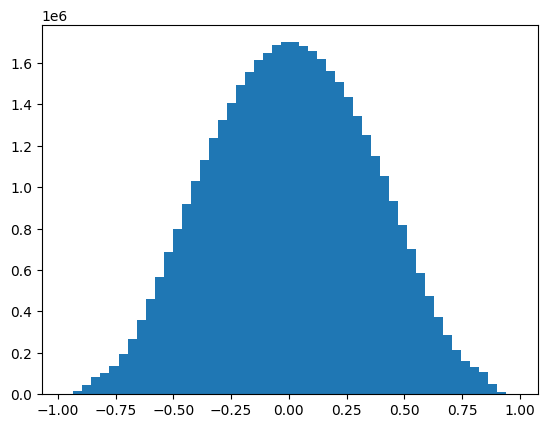

In [30]:
plt.hist(train_latent.flatten(), bins = 50)

In [33]:
from datetime import datetime

# Get the current date and time
now = datetime.now()

# Format for a directory name
dir_name = now.strftime("%Y-%m-%d_%H-%M-%S")

print(dir_name)


2025-01-17_14-33-18


In [38]:
80%20

0

In [10]:
arsch = torch.load("/Users/saidharb/Documents/LocalDocuments/Master-Thesis/Point-Cloud-Reconstruction/models/trained_models/2025-01-24_16-49-26/last.pth")
print(arsch['config'])

{'learning_rate': 0.001, 'batch_size': 2, 'max_epochs': 30, 'optimizer': 'Adam', 'model_type': 'pointnet2_cls_ssg', 'save_interval': 5, 'early_stopping': 20, 'start_time': '2025-01-24_16-49-26', 'final_epoch': 7, 'training_time_min': 0.22}


/var/folders/97/07fn6f7n48j71zk65dskp3gm0000gn/T/ipykernel_17995/1564996221.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  arsch = torch.load("/Users/saidharb/Documents

In [48]:
type(arsch)

dict

In [18]:
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv("/Users/saidharb/Documents/LocalDocuments/Master-Thesis/Point-Cloud-Reconstruction/models/trained_models/test_run_2/metrics.csv")

# Access columns as lists
column1 = df["epoch"].tolist()
column2 = df["learning_rate"].tolist()

# Print the lists
print("epoch", column1)
print("learning_rate:", column2)


epoch [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
learning_rate: [0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001]


In [20]:
data_dict = df.to_dict(orient='list')
print(data_dict.keys())

dict_keys(['epoch', 'learning_rate', 'train_mse', 'train_rmse', 'train_mae', 'val_mse', 'val_rmse', 'val_mae'])


In [22]:
print(len(data_dict['train_mse']))

11


In [85]:
class EarlyStopping():

    def __init__(self, max_epochs):
        self.max_epochs = max_epochs
        self.epoch = 0
        self.best_loss = float('inf')
        self.best_epoch = 0

    def update(self, loss):
        if loss < self.best_loss:
            self.best_epoch = self.epoch
            self.epochs = 0
            self.best_loss = loss
        else:
            self.epochs += 1
    
        if self.epochs == self.max_epochs:
            print(f"Early stopping: Validation loss did not decrease for {self.max_epochs} epochs "
                  f"from {self.best_loss:.8f} since epoch {self.best_epoch + 1}.")
            return True
        return False


In [98]:
import time

start_time = time.time()
# Simulate some processing
time.sleep(2)  # Simulates 5 seconds of processing
minutes, seconds = divmod(time.time() - start_time, 60)
print(f"Training finished in {int(minutes)}:{int(seconds):02} minutes.\n"
      f"--- DONE ---\n")

Training finished in 0:02 minutes.
--- DONE ---



In [100]:
import logging
import time

# Configure logging
logging.basicConfig(
    level=logging.INFO,  # Set the logging level
    format="%(asctime)s - %(levelname)s - %(message)s",  # Log message format
    handlers=[
        logging.FileHandler("training.log"),  # Log to a file
    #    logging.StreamHandler()  # Also log to the console
    ]
)

# Example usage in a training script
start_time = time.time()
logging.info("Training started.")

for epoch in range(1, 6):  # Simulate 5 epochs
    time.sleep(1)  # Simulate training time
    loss = 0.1 * epoch  # Example loss value
    elapsed_time = time.time() - start_time
    logging.info(f"Epoch {epoch}: Loss={loss:.4f}, Time Elapsed={elapsed_time:.2f}s")

end_time = time.time()
total_time = (end_time - start_time) / 60.0
minutes, seconds = divmod(total_time * 60, 60)
logging.info(f"Training finished in {int(minutes)}:{int(seconds):02} minutes.")
logging.info("--- DONE ---")


2025-01-20 11:31:06,804 - INFO - Training started.
2025-01-20 11:31:07,810 - INFO - Epoch 1: Loss=0.1000, Time Elapsed=1.01s
2025-01-20 11:31:08,813 - INFO - Epoch 2: Loss=0.2000, Time Elapsed=2.01s
2025-01-20 11:31:09,820 - INFO - Epoch 3: Loss=0.3000, Time Elapsed=3.02s
2025-01-20 11:31:10,826 - INFO - Epoch 4: Loss=0.4000, Time Elapsed=4.02s
2025-01-20 11:31:11,833 - INFO - Epoch 5: Loss=0.5000, Time Elapsed=5.03s
2025-01-20 11:31:11,836 - INFO - Training finished in 0:05 minutes.
2025-01-20 11:31:11,837 - INFO - --- DONE ---


In [103]:
class Logger():
    def __init__(self, save_dir):
        self.logger = logging.getLogger("Training")
        self.logger.setLevel(logging.INFO)
        file_handler = logging.FileHandler(os.path.abspath(os.path.join(save_dir, "info.log")))
        file_handler.setFormatter(logging.Formatter("%(asctime)s - %(levelname)s - %(message)s"))
        self.logger.addHandler(file_handler)
        self.logger.addHandler(logging.StreamHandler())

    def log(self, information):
        self.logger.info(information)

In [104]:
z = Logger("")

In [107]:

z.log("Bless you!")
z.log("hehe")

Bless you!
2025-01-20 11:57:01,728 - INFO - Bless you!
hehe
2025-01-20 11:57:01,733 - INFO - hehe


In [79]:
a = EarlyStopping(3)

In [80]:
a.update(1.0)

False

In [81]:
a.update(1.1)

False

In [82]:
a.update(2.0)

False

In [83]:
a.update(2.1)

Early stopping: Validation loss did not decrease for 3 epochs from 1.00000000 since epoch 1.


True

In [84]:
a.update(3.0)

False

In [120]:
!WANDB_API_KEY=12

In [121]:
print(os.getenv("WANDB_API_KEY"))

None


In [119]:
import os

# Check if the environment variable is set
api_key = os.getenv("WANDB_API_KEY")

if api_key:
    print("API key is provided.")
else:
    print("No API key found. Please set the WANDB_API_KEY environment variable.")


No API key found. Please set the WANDB_API_KEY environment variable.


In [151]:
import csv

train_mae = [1,2,3,4,9,10]
val_mae = [5,2,8,9,11,245]


def write_to_csv(*lists, arsch = 0):
    print(len(lists[0]))
    print(arsch)
    epochs = list(range(1, len(lists[0]) + 1))
    headers = ['epoch', 'train_mae', 'val_mae']
    with open("test.csv", mode='w', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        writer.writerow(headers)
        for row in zip(epochs, *lists):
            writer.writerow(row)

write_to_csv(train_mae, val_mae, arsch = 3)

6
3


In [131]:
print(type(range(0,3)))

<class 'range'>


In [140]:
a = [1,2,3,4,5]
b = [1,2,3,4,5]
c = zip(a, b)

In [142]:
d = list(range(1, len(c[0]) + 1))

TypeError: 'zip' object is not subscriptable

In [147]:
list(range(1,2))

[1]

In [149]:
z = 3
list(range(1,3+2))

[1, 2, 3, 4]

In [1]:
9.765625e-07 > 1e-6

False

In [2]:
lol = "/Users/saidharb/Documents/LocalDocuments/Master-Thesis/Point-Cloud-Reconstruction/models/trained_models/test_run/last.pth."
import os
a = os.path.basename(lol)
print(a)

last.pth.


In [4]:
a = [2, 3, 2, 5, 4, 1]
maxi = a.index(max(a))
print(maxi)

3


In [1]:
import sys
import matplotlib.pyplot as plt
import os
sys.path.append(os.path.abspath("../code"))

In [2]:
import torch
from utils import CosineAnnealWarmRestart

In [11]:
lr = [0.001, 0.000993844785880539, 0.000975530705321762, 0.0009455087117679744, 0.0009045180463377549, 0.0008535680352542143, 0.0007939132368836219, 0.0007270225503447864, 0.0006545430463377549, 0.0005782594107968633, 0.0005000499999999999, 0.0004218405892031367, 0.00034555695366224505, 0.0002730774496552136, 0.0002061867631163781, 0.0001465319647457856, 9.558195366224507e-05, 5.459128823202553e-05, 2.456929467823799e-05, 6.255214119460927e-06, 0.0008, 0.000797809032052541, 0.0007912601329134857, 0.0007804250536922468, 0.0007654225057841582, 0.0007464168602435863, 0.0007236163469002603, 0.0006972707729496838, 0.0006676687860132254, 0.0006351347116543746, 0.000600025, 0.0005627243203981663, 0.0005236413469002603, 0.0004832042807425628, 0.0004418561588838981, 0.00040005000000000016, 0.0003582438411161021, 0.0003168957192574372, 0.00027645865309973986, 0.0002373756796018338, 0.0002000750000000001, 0.00016496528834562544, 0.0001324312139867748, 0.00010282922705031628, 7.648365309973982e-05, 5.3683139756413745e-05, 3.467749421584175e-05, 1.9674946307753348e-05, 8.839867086514417e-06, 2.2909679474590534e-06, 0.00064, 0.0006392206178806308, 0.0006368862685938655, 0.0006330083248547812, 0.0006276056796154652, 0.0006207046540204514, 0.0006123388691727502, 0.0006025490823352137, 0.0005913829883652485, 0.0005788949873502645, 0.000565145919575917, 0.0005502027691183514, 0.0005341383375045167, 0.0005170308890304443, 0.0004989637694654655, 0.0004800250000000001, 0.0004603068484151654, 0.0004399053795634211, 0.0004189199873502645, 0.0003974529104971138, 0.00037560873444453447, 0.0003534938818224858, 0.0003312160939699653, 0.00030888390603003494, 0.0002866061181775144, 0.0002644912655554657, 0.00024264708950288633, 0.00022118001264973564, 0.00020019462043657896, 0.00017979315158483467, 0.0001600750000000001, 0.00014113623053453462, 0.00012306911096955566, 0.00010596166249548333, 8.989723088164853e-05, 7.495408042408303e-05, 6.120501264973561e-05, 4.871701163475153e-05, 3.755091766478639e-05, 2.7761130827249893e-05, 1.9395345979548636e-05, 1.2494320384534943e-05, 7.091675145218871e-06, 3.2137314061345987e-06, 8.793821193692481e-07, 0.0005120000000000001, 0.0005117228346470955, 0.0005108919388668175, 0.000509509112194405, 0.0005075773495245066, 0.0005051008346249059, 0.0005020849310754128, 0.0004985361706515426, 0.0004944622391781462, 0.0004898719598836238, 0.0004847752742907775, 0.0004791832206856865, 0.00047310791021123734, 0.00046656250063708567, 0.0004595611678628564, 0.0004521190752163025, 0.0004442523406129133, 0.0004359780016480982, 0.0004273139786975499, 0.00041827903610570005, 0.00040889274154632825, 0.00039917542364333774, 0.0003891481279434828, 0.00037883257133640067, 0.00036825109502066445, 0.0003574266161177223, 0.0003463825780385148, 0.0003351428997102679, 0.000323731923773422, 0.0003121743638608939, 0.00030049525107385096, 0.00028871987976991935, 0.0002768737527812384, 0.00026498252618100527, 0.00025307195371813247, 0.00024116783104036378, 0.0002292959398266442, 0.00021748199194974486, 0.0002057515737900722, 0.00019413009082126513, 0.00018264271258759652, 0.0001713143181923451, 0.00016016944241519735, 0.00014923222257537877, 0.00013852634625559446, 0.0001280750000000001, 0.00011790081909731037, 0.00010802583855780388, 9.84714453903978e-05, 8.925833228314858e-05, 8.040645278749768e-05, 7.19349781033223e-05, 6.38622555583853e-05, 5.6205768872109096e-05, 4.898210028973224e-05, 4.220689466885889e-05, 3.589482559618128e-05, 3.00595636077577e-05, 2.4713746581676186e-05, 1.986895236722455e-05, 1.553567370984677e-05, 1.1723295526193021e-05, 8.440074578480014e-06, 5.693121592182435e-06, 3.4883858557853494e-06, 1.8306423359496839e-06, 7.234813359979968e-07, 1.6930072011677432e-07, 0.0004096000000000001, 0.00040950144724862485, 0.0004092058838677083, 0.0004087135943855475, 0.0004080250527116217, 0.0004071409216803768, 0.00040606205241313823, 0.0004047894834987673, 0.00040332443999384837, 0.0004016683322433709, 0.0003998227545230406, 0.00039778948350452766, 0.0003955704765451278, 0.0003931678698034849, 0.00039058397618318746, 0.00038782128310621875, 0.0003848824501184048, 0.00038177030632916475, 0.0003784878476880283, 0.0003750382341005423, 0.0003714247863863427, 0.00036765098308232016, 0.0003637204570939571, 0.0003596369921980595, 0.00035540451940025, 0.00035102711315072995, 0.0003465089874219512, 0.0003418544916519763, 0.0003370681065574292, 0.0003321544398200703, 0.00032711822165114557, 0.0003219643002377814, 0.00031669763707580846, 0.00031132330219350694, 0.00030584646927087154, 0.0003002724106590949, 0.0002946064923050637]

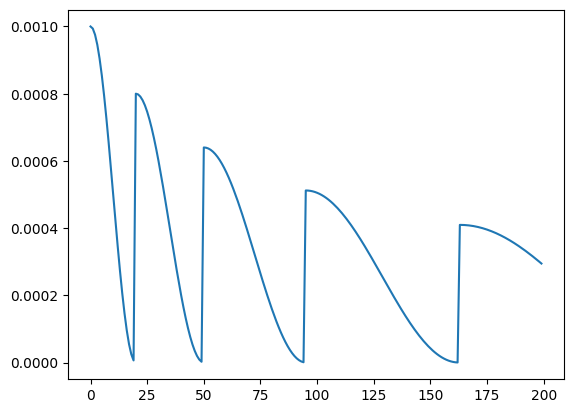

In [12]:
plt.plot(lr)